In [ ]:
import numpy as np
import numpy.linalg as la
from scipy.linalg import rq
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

np.set_printoptions(precision = 8, suppress = True)

In [ ]:
def f(s, p):
  red1 = [0, 0, 0, 0, -p[2]*s[0], -p[2]*s[1], -p[2]*s[2], -p[2]*s[3], p[1]*s[0], p[1]*s[1], p[1]*s[2], p[1]*s[3]]
  red2 = [p[2]*s[0], p[2]*s[1], p[2]*s[2], p[2]*s[3], 0, 0, 0, 0, -p[0]*s[0], -p[0]*s[1], -p[0]*s[2], -p[0]*s[3]]

  return np.array([red1, red2], dtype = float)

In [ ]:
def SVD(pts1, pts2):
    A = []
    n = len(pts1)

    for i in range(n):
        dve = f(pts1[i], pts2[i])
        A.append(dve[0])
        A.append(dve[1])

    A = np.array(A)

    _, _, Vh = la.svd(A)

    P = Vh[-1].reshape(3, 4)
    P = P / P[2, 3]

    return P

In [ ]:
def centar_kamere(T):
  M = T[:, :3]
  p4 = T[:, 3]
  C = -la.inv(M) @ p4
  C = np.append(C, 1.0)
  return C

In [ ]:
def dekompozicija(M):
  M = M[:, :3]
  R, Q = rq(M)
  T = np.diag(np.sign(np.diag(R)))

  R = R @ T
  R = R / R[2, 2]
  Q = T @ Q
  return R, Q

In [ ]:
p1 = [489, 612, 1]
p2 = [745, 668, 1]
p3 = [617, 833, 1]
p4 = [321, 749, 1]
p5 = [734, 904, 1]
p6 = [613, 1085, 1]
p7 = [357, 987, 1]

piksel = [p1, p2, p3, p4, p5, p6, p7]

In [ ]:
p11 = [0, 0, 3, 1]
p22 = [0, 3, 3, 1]
p33 = [3, 3, 3, 1]
p44 = [3, 0, 3, 1]
p55 = [0, 3, 0, 1]
p66 = [3, 3, 0, 1]
p77 = [3, 0, 0, 1]

svetske = [p11, p22, p33, p44, p55, p66, p77]

In [ ]:
T = SVD(svetske, piksel)
print("Matrica kamere:\n", T)
print()

K, A = dekompozicija(T)
print("Matrica kalibracije kamere:\n", K)
print()

C = centar_kamere(T)
print("Pozicija centra kamere:\n", C)
print()

print("Spoljasnja matrica kamere:\n", A)
print()

Matrica kamere:
 [[-64.29493965  57.68806858 -21.08151117 501.16258366]
 [  6.595971    -0.76330623 -94.57437687 833.00110039]
 [ -0.04553726  -0.02663894  -0.03422044   1.        ]]

Matrica kalibracije kamere:
 [[1309.15247673  -10.37233442  534.22294508]
 [   0.         1309.24329365  747.62606796]
 [   0.            0.            1.        ]]

Pozicija centra kamere:
 [10.81450683  6.83982032  9.50693439  1.        ]

Spoljasnja matrica kamere:
 [[-0.48158474  0.87545614 -0.0406533 ]
 [ 0.49363562  0.23263399 -0.83797691]
 [-0.72415469 -0.42362481 -0.54418931]]



In [ ]:
slika1 = T @ p11
print(slika1 / slika1[2])
print()

slika2 = T @ p22
print(slika2 / slika2[2])
print()

slika3 = T @ p33
print(slika3 / slika3[2])
print()

slika4 = T @ p44
print(slika4 / slika4[2])
print()

slika5 = T @ p55
print(slika5 / slika5[2])
print()

slika6 = T @ p66
print(slika6 / slika6[2])
print()

slika7 = T @ p77
print(slika7 / slika7[2])
print()

[488.01868804 612.11889777   1.        ]

[747.45033861 669.16248392   1.        ]

[614.11756252 832.5022896    1.        ]

[322.1040652  748.05540984   1.        ]

[732.78894956 902.86530256   1.        ]

[ 614.37081996 1085.55218168    1.        ]

[357.05579068 987.72370346   1.        ]



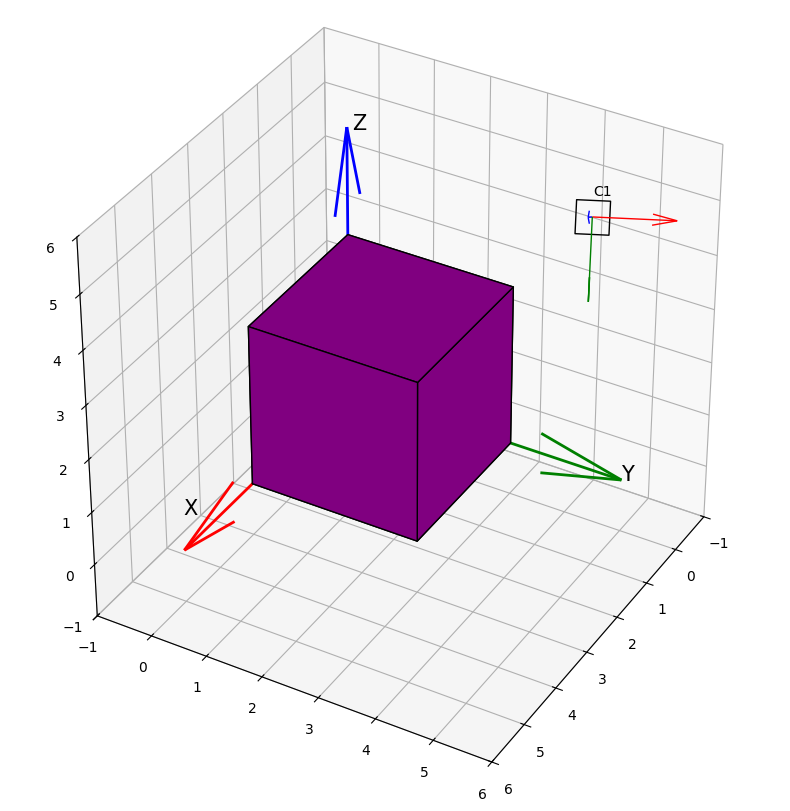

In [ ]:
vertices = np.array([[0, 0, 0], [3, 0, 0], [3, 3, 0], [0, 3, 0],
                     [0, 0, 3], [3, 0, 3], [3, 3, 3], [0, 3, 3]])
faces = [
    [vertices[0], vertices[1], vertices[2], vertices[3]],
    [vertices[4], vertices[5], vertices[6], vertices[7]],
    [vertices[0], vertices[3], vertices[7], vertices[4]],
    [vertices[1], vertices[2], vertices[6], vertices[5]],
    [vertices[0], vertices[1], vertices[5], vertices[4]],
    [vertices[3], vertices[2], vertices[6], vertices[7]]]

x_cam = A[0]
y_cam = A[1]
z_cam = A[2]

fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(111, projection = '3d')

ax.add_collection3d(Poly3DCollection(faces, facecolors = 'purple', edgecolors = 'k', alpha = 1))

center = np.array([0, 0, 0])
axis_length = 5
ax.quiver(center[0], center[1], center[2], axis_length, 0, 0, color = 'r', linewidth = 2)
ax.quiver(center[0], center[1], center[2], 0, axis_length, 0, color = 'g', linewidth = 2)
ax.quiver(center[0], center[1], center[2], 0, 0, axis_length, color = 'b', linewidth = 2)

ax.text(center[0] + axis_length, center[1], center[2] + 0.7, 'X', color = 'k', fontsize = 15)
ax.text(center[0], center[1] + axis_length, center[2], 'Y', color = 'k', fontsize = 15)
ax.text(center[0], center[1] + 0.1, center[2] + axis_length, 'Z', color = 'k', fontsize = 15)

cam_axis_length = 1
ax.quiver(C[0], C[1] + 3, C[2] + 3, *x_cam, color = 'r', length = cam_axis_length, linewidth = 1)
ax.quiver(C[0], C[1] + 3, C[2] + 3, *y_cam, color = 'g', length = cam_axis_length, linewidth = 1)
ax.quiver(C[0], C[1] + 3, C[2] + 3, *z_cam, color = 'b', length = cam_axis_length, linewidth = 1)

ax.text(C[0], C[1] + 3, C[2] + 3.3, 'C1', color = 'k')

s = 0.2
offset = np.array([0, 3, 3])
quad_local = np.array([
    [-s, -s, 0],
    [ s, -s, 0],
    [ s,  s, 0],
    [-s,  s, 0]
])
R = np.vstack([x_cam, y_cam, z_cam]).T
quad_world = (R @ quad_local.T).T + C[:3] + offset
ax.add_collection3d(Poly3DCollection([quad_world], facecolor = 'white', edgecolor = 'k', alpha = 0))

ax.set_xlim([-1, 6])
ax.set_ylim([-1, 6])
ax.set_zlim([-1, 6])
ax.view_init(elev = 35, azim = 30)
ax.set_box_aspect([1, 1, 1])

plt.show()